In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

#CDMS = os.environ["CDMS"] # set in .bash_profile
#stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
#plt.style.use(stylesheet)

#sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
#import setup

/usr/local/lib/python3.10/dist-packages/CDMSDataCatalog/CDMSDataCatalog.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
# Z1 0V R37
series_list=['23240104_051944', '23231222_074513', 
'23231221_235414', '23231221_223301', 
'23231221_162803']
# Z1 0V R38
#series_list=['23240310_103543', '23240310_045613',
#'23240310_015547', '23240305_084620', 
#'23240305_050626', '23240305_030542', 
#'23240221_012437']

In [4]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [5]:
filepath = [f'/scratch/perry/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_{i}.root' for i in series_list]

In [6]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [7]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")

In [8]:
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [9]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = (["SeriesNumber", "PTOFamps", "PTINTall", "EventNumber", "EventTime", "PTOFchisq"] + [chan + "peaknum" for chan in channels])
df_rqs = df_filtered.AsNumpy(RQs)

In [10]:
def pt2keV(x):
    recoilE = x * calibFac
    return recoilE

In [11]:
calibFac = 7230000
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps'])

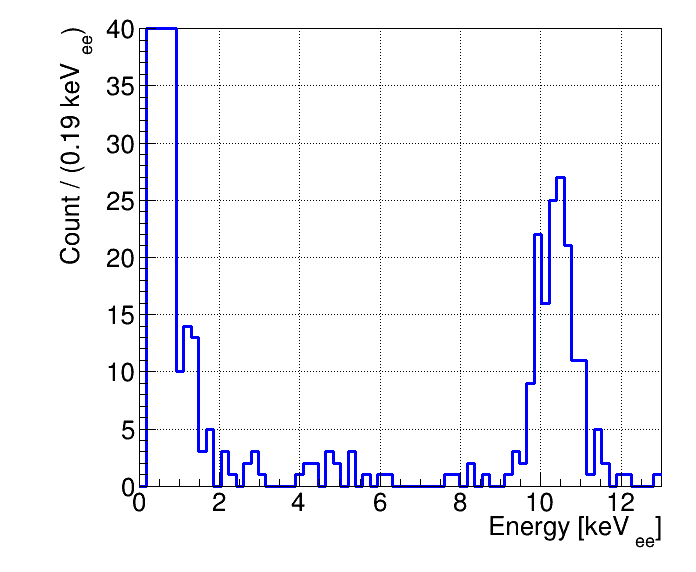

In [12]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 13
nbins = 70
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

for value in data:
    h.Fill(value)
h.SetLineWidth(3)
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
h.SetMaximum(40)
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-30, 80)

c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.SetGrid(1,1)
#c.SetLogy()
c.Draw()

In [13]:
K_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= 6) & (df_rqs['PTOFamps_keVee'] <= 16)]

 **********
 **   19 **SET PRINT           1
 **********
 **********
 **   20 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.03000e+01  1.50000e-01    9.50000e+00  1.10000e+01
     2 #sigma1      1.00000e-01  4.50000e-02    1.00000e-02  1.00000e+00
     3 frac         8.70000e-01  6.50000e-02    0.00000e+00  1.00000e+00
 **********
 **   21 **SET ERR         0.5
 **********
 **********
 **   22 **SET PRINT           1
 **********
 **********
 **   23 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **   24 **MIGRAD        1500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=249.334 FROM MIGRAD    STATUS=INITIATE       27 CALLS          28 TOTAL
                     EDM= unknown      STRATEGY= 1      NO ERROR MATRIX       
  E

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


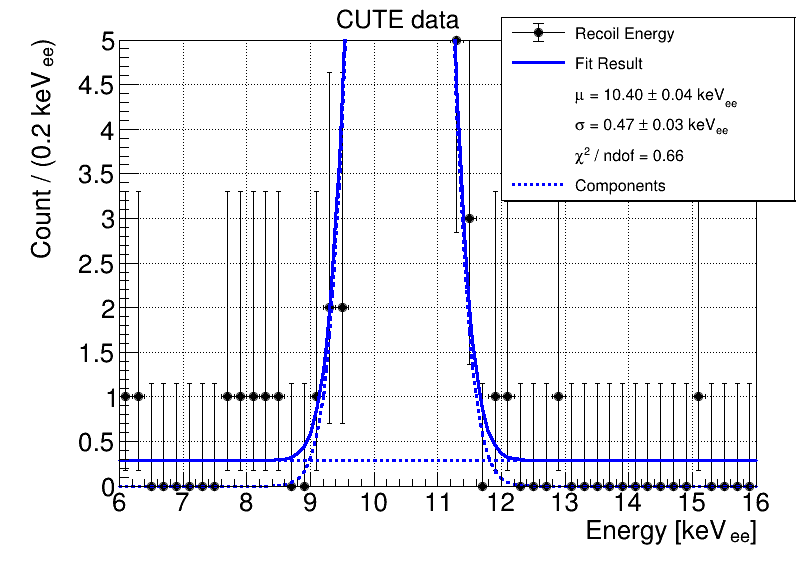

In [17]:
ROOT.gStyle.SetOptStat(0)
bins_start = 6
bins_end = 16
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

mean = ROOT.RooRealVar("#mu1", "#mu", 10.3, 9.5, 11)
sigma = ROOT.RooRealVar("#sigma1", "#sigma", 0.1, 0.01, 1)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)

flat = ROOT.RooUniform("flat", "Uniform PDF", x)

frac = ROOT.RooRealVar("frac", "signal fraction", 0.87, 0.0, 1.0)

model = ROOT.RooAddPdf("model", "gauss + flat", ROOT.RooArgList(gauss, flat), ROOT.RooArgList(frac))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("CUTE data"))
frame.SetLabelSize(0.05)
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name("Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("gauss"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("flat"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean, sigma))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean, sigma))
mean_upper_bound = upper_bound.getVal()
mean_lower_bound = lower_bound.getVal()
x.setRange("gaussRange", mean_lower_bound, mean_upper_bound)

frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
model.plotOn(frame_narrow,
             ROOT.RooFit.Range("gaussRange"),
             ROOT.RooFit.Name("model_narrow"))
nbins = np.round(mean_upper_bound - mean_lower_bound) / bindiff
chi2_narrow = frame_narrow.chiSquare(3)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu = " + f"{mean.getVal():.2f} #pm {mean.getPropagatedError(fit_result):.2f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma = " + f"{sigma.getVal():.2f} #pm {sigma.getPropagatedError(fit_result):.2f}" + " keV_{ee}", "")
legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

frame.SetMinimum(0)
frame.SetMaximum(5)  # Adjust based on your data
#frame.SetMaximum(14)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.07)
c.SetGrid(1,1)
frame.Draw()
legend.Draw()
c.Draw()

In [18]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean, sigma))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean, sigma))

mean_upper_bound = upper_bound.getVal()
err_upper_bound = upper_bound.getPropagatedError(fit_result)
mean_lower_bound = lower_bound.getVal()
err_lower_bound = lower_bound.getPropagatedError(fit_result)

print('The range of the peak is ' + str_with_err(mean_lower_bound, err_lower_bound) + ' keV to ' + str_with_err(mean_upper_bound, err_upper_bound) + ' keV')

uniform_norm = ROOT.RooFormulaVar("norm", "1 - @0", ROOT.RooArgList(frac))
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data)) # make sure this is up to date!
binwidth = ROOT.RooRealVar("#binwidth", "#binwidth", (bins_end - bins_start) / nbins)
uniform_height = ROOT.RooRealVar("#height", "#height", 1 / (bins_end - bins_start))

uniform_count = ROOT.RooProduct("#count", "(1 - frac1) * nevent * binwidth * 1 / (range)", ROOT.RooArgList(uniform_norm, nevent, binwidth, uniform_height))

uniform_magnitude = uniform_count.getVal() # count / bin
uniform_magnitude_err = uniform_count.getPropagatedError(fit_result) # count / bin
fitted_bins = (mean_upper_bound - mean_lower_bound) / ((bins_end - bins_start) / nbins)
max_bins = (mean_upper_bound + err_upper_bound - mean_lower_bound + err_lower_bound) / ((bins_end - bins_start) / nbins)
min_bins = (mean_upper_bound - err_upper_bound - mean_lower_bound - err_lower_bound) / ((bins_end - bins_start) / nbins)
fitted_bins_err = abs(np.mean([max_bins, min_bins]) - fitted_bins)

integrated_uniform = uniform_magnitude * fitted_bins
integrated_uniform_err = uniform_magnitude_err * fitted_bins #np.sqrt( (uniform_magnitude_err * fitted_bins)**2 + (uniform_magnitude * fitted_bins_err)**2 )

rangeCut = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound)
rangeCut_max = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound - err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound + err_upper_bound)
rangeCut_min = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound + err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound - err_upper_bound)

count = sum(rangeCut)
count_stat = np.sqrt(count)
count_variation = np.mean([abs(count - sum(rangeCut_min)), abs(count - sum(rangeCut_max))])
count_err = np.sqrt( count_stat**2 + count_variation**2 )

print('The number of events inside the peak range is ' + str(round(count, 2)) + ' +/- ' + str(round(count_err, 2)))
print('The number of events in the background of the peak range is ' + str(round(integrated_uniform, 2)) + ' +/- ' + str(round(integrated_uniform_err, 2)))

peak_evts = count - integrated_uniform
peak_evts_err = np.sqrt( count_err ** 2 + integrated_uniform_err ** 2 )
print('The number of non-background events in the peak is ' + str(round(peak_evts, 2)) + ' +/- ' + str(round(peak_evts_err, 2)))

The range of the peak is 9.0(1) keV to 11.8(1) keV
The number of events inside the peak range is 156 +/- 12.5
The number of events in the background of the peak range is 4.06 +/- 1.25
The number of non-background events in the peak is 151.94 +/- 12.56


In [19]:
nevent_window = sum((df_rqs['PTOFamps_keVee'] >= bins_start) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound))

# signal events in peak
print('The fraction of signal events in the peak is ' + str(round(peak_evts / nevent_window * 100, 2)) + ' +/- ' + str(round(peak_evts_err / nevent_window * 100, 2)))

# background events in the peak
print('The fraction of background events in the peak is ' + str(round(integrated_uniform / nevent_window * 100, 2)) + ' +/- ' + str(round(integrated_uniform_err / nevent_window * 100, 2)))

# background events below peak
fitted_bins_tail = (mean_lower_bound - bins_start) / ((bins_end - bins_start) / nbins)
integrated_uniform_tail = uniform_magnitude * fitted_bins_tail
integrated_uniform_tail_err = uniform_magnitude_err * fitted_bins_tail
print('The fraction of background events in the tail is ' + str(round(integrated_uniform_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(integrated_uniform_tail_err / nevent_window * 100, 2)))

# signal events below peak
signal_tail = nevent_window - count - integrated_uniform_tail
signal_tail_err = np.sqrt(count_err**2 + integrated_uniform_tail_err**2)
print('The fraction of signal events in the tail is ' + str(round(signal_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(signal_tail_err / nevent_window * 100, 2)))

# non-peak signal to peak signal
ratio = signal_tail / peak_evts
ratio_err = np.sqrt( (signal_tail_err / peak_evts)**2 + (signal_tail / peak_evts**2 * peak_evts_err)**2)
print('The ratio of non-peak signal to peak signal is ' + str(round(ratio, 3)) + ' +/- ' + str(round(ratio_err, 3)))

The fraction of signal events in the peak is 93.22 +/- 7.71
The fraction of background events in the peak is 2.49 +/- 0.77
The fraction of background events in the tail is 2.63 +/- 0.81
The fraction of signal events in the tail is 1.66 +/- 7.71
The ratio of non-peak signal to peak signal is 0.018 +/- 0.083
